# Figure 5: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/app/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

/app/.venv/lib/python3.9/site-packages/datajoint/plugin.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-18 14:13:07,374][INFO]: Connecting admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
[2026-02-18 14:13:07,560][INFO]: Connected admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials
from vr4mice.schema.decision import PredictionModel, DecisionPoints, InclusionStatus, ExperimentMember, LabelSet, Label

from statsmodels.stats.anova import AnovaRM
import scipy.stats as stats

from vr4mice.analysis.stats import get_multi_p_values_global, get_multi_p_values_binned, plot_aperture_heatmap

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [5]:
task_type_key = {"set_name": "contrast_white_target",
                 "stage_name": "multi_occlusion",}

In [6]:
sessions_list = list(
                (InclusionStatus * ExperimentMember & {"included": 1} & task_type_key).fetch(
                    "dataset"
                )
            )

len(sessions_list)

25

In [7]:
# This takes a while to fetch because we need to fetch data for all trials
dataset_list = []
for d in sessions_list:
    print(d)
    try:
        dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str[0]

31726_2025-03-27_1
31726_2025-03-28_1
31728_2025-03-11_1
31728_2025-03-14_1
J729_2024-12-11_1
J729_2024-12-12_1
J729_2024-12-13_1
J729_2024-12-15_1
Jacana_2024-08-21_1
Jacana_2024-08-22_1
Kiwi_2024-08-19_1
Kiwi_2024-08-20_1
Kiwi_2024-08-21_1
Lemming_2024-08-14_1
Lemming_2024-08-15_1
Lemming_2024-08-19_1
Nightingale_2024-08-15_1
Nightingale_2024-08-16_1
Nightingale_2024-08-21_1
Nightingale_2024-08-22_1
Oribi_2024-08-26_1
Oribi_2024-08-27_1
Oribi_2024-08-29_1
Pheasant_2024-08-26_1
Pheasant_2024-08-28_1


In [8]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

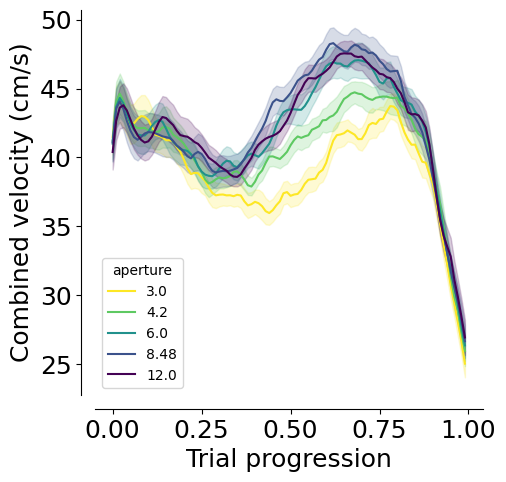

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax = ax
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

mean_mouse.sort_values("aperture", inplace=True)
mean_mouse["aperture"] = mean_mouse.aperture.astype("str")

sns.lineplot(
    data=mean_mouse,
    x="trial_length",
    y="velocity",
    palette=plotting.colors_multi_aperture,
    hue="aperture",
    errorbar="se",
    ax=ax,
)

sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.savefig(save_fig_path + "figure5_velocity.svg", transparent=False)

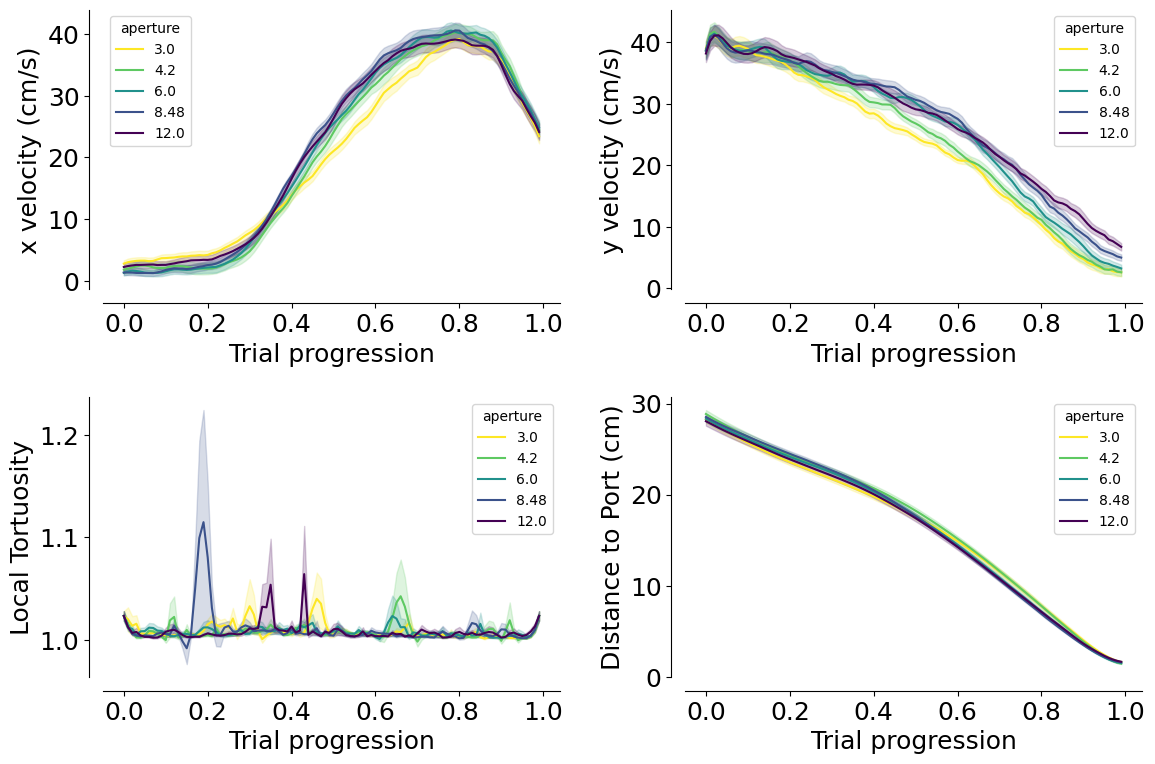

In [10]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for (i, label), label_str in zip(enumerate(
    ["velocity_x_fliped", "velocity_y", "local_tortuosity", "distance_to_choice"]
), ["x velocity (cm/s)", "y velocity (cm/s)", "Local Tortuosity", "Distance to Port (cm)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else plotting.colors_multi_aperture
        ),
        hue="aperture",
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)
    
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure5_velocity_tortuosity_distance.svg", bbox_inches="tight", transparent=True)

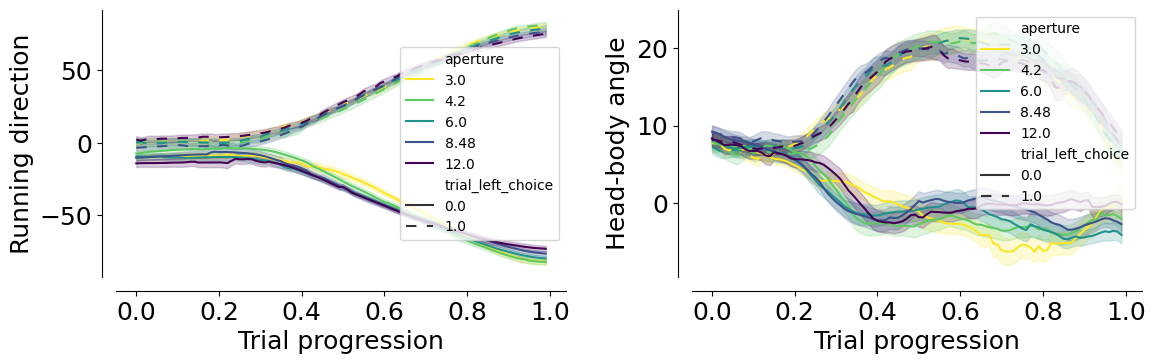

In [11]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

dash_styles = {
    mean_mouse.trial_left_choice.unique()[0]: "",         # Solid
    mean_mouse.trial_left_choice.unique()[1]: (5, 5)      # Dashed
}

for (i, label), label_str in zip(enumerate(["heading_dir", "head_angle"]), 
                                 ["Running direction", "Head-body angle"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_multi_aperture,
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        dashes=dash_styles,
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)


plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure5_heading_dir_head_angle.svg", bbox_inches="tight", transparent=True)

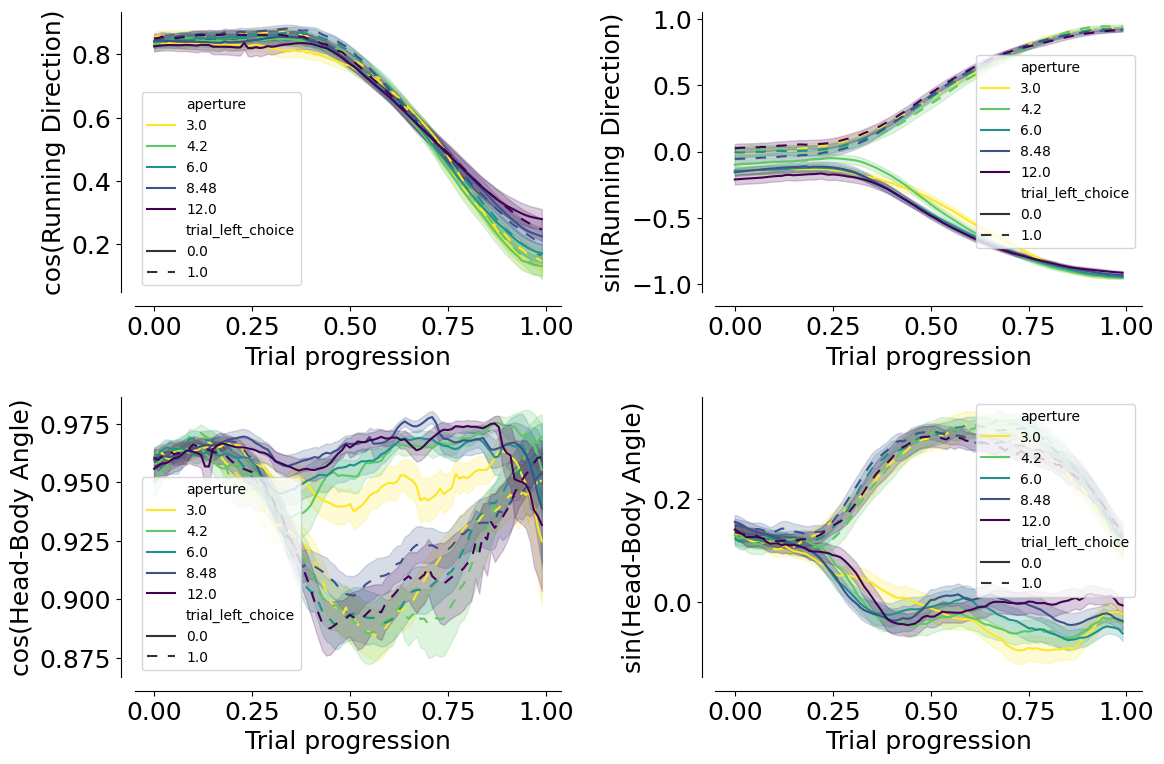

In [12]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

dash_styles = {
    mean_mouse.trial_left_choice.unique()[0]: "",         # Solid
    mean_mouse.trial_left_choice.unique()[1]: (5, 5)      # Dashed
}

for (i, label), label_str in zip(enumerate(
    ["heading_dir_cos", "heading_dir_sin", "head_angle_cos", "head_angle_sin"]
), ["cos(Running Direction)", "sin(Running Direction)", "cos(Head-Body Angle)", "sin(Head-Body Angle)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_multi_aperture,
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        ax=ax[i],
        dashes=dash_styles,
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)


plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure5_heading_dir_head_angle_cos_sin.svg", bbox_inches="tight", transparent=True)

In [13]:
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

optimal_df =  interpolated_df.groupby(["dataset", "mouse_name", "trial", "aperture"], as_index=False).mean()
optimal_df =  interpolated_df.groupby(["dataset", "mouse_name", "aperture"], as_index=False).mean()

In [14]:
optimal_df["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    optimal_df.loc[optimal_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  3.1376 4.0000 96.0000 0.0180



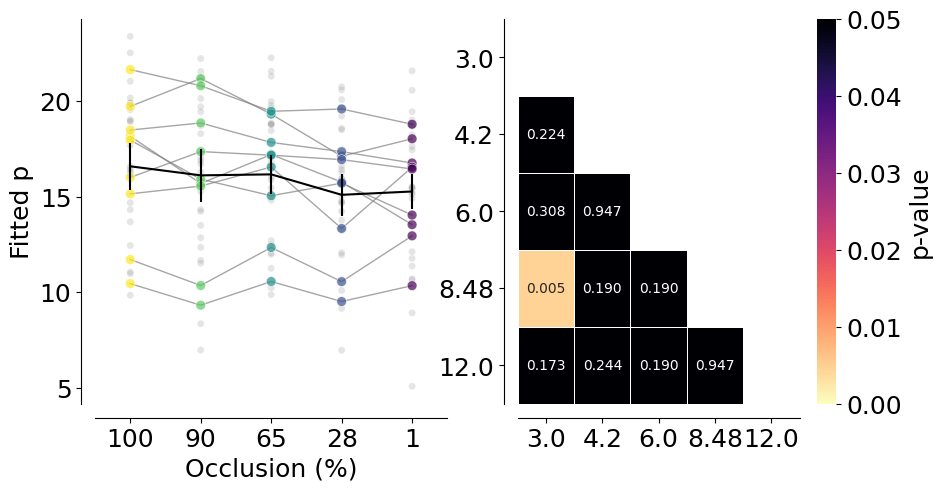

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_mouse=True,
    cmap=plotting.colors_multi_aperture,
)
ax[0].invert_xaxis()

ax[0].set_xlabel("Occlusion (%)")
ax[0].set_ylabel("Fitted p")
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

p_values = get_multi_p_values_global(optimal_df, y_var="optimal_p")
plot_aperture_heatmap(p_values, ax= ax[1])
sns.despine(offset=10, ax=ax[1])

print(AnovaRM(counts, depvar="count", subject="dataset", within=["aperture"]).fit())
plt.savefig(save_fig_path + "figure5_fitted_p.svg", transparent=True)

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  3.1376 4.0000 96.0000 0.0180



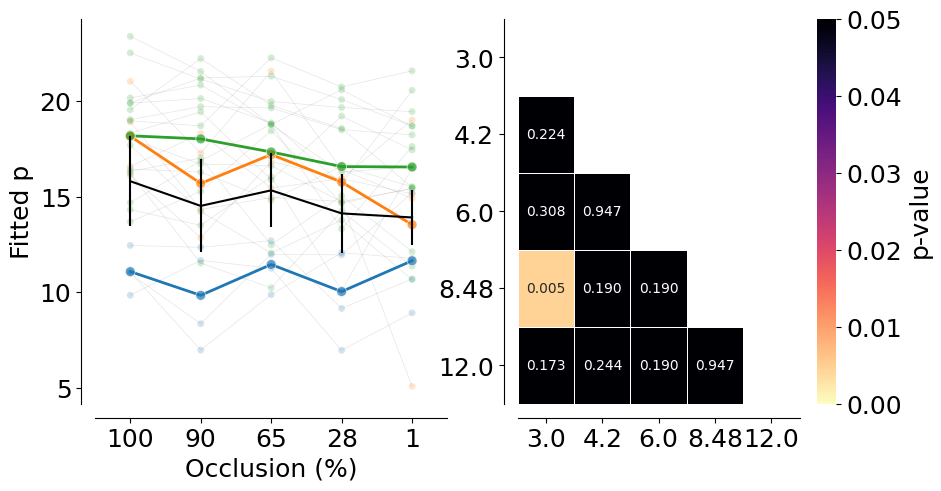

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

counts = (
    optimal_df
    .groupby(["lab_id", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_lab=True,
    cmap=plotting.colors_multi_aperture,
)
ax[0].invert_xaxis()

ax[0].set_xlabel("Occlusion (%)")
ax[0].set_ylabel("Fitted p")
ax[0].set_xlim(-0.5, 4.5)

ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

p_values = get_multi_p_values_global(optimal_df,  y_var="optimal_p")
plot_aperture_heatmap(p_values, ax= ax[1])

sns.despine(offset=10, ax=ax[1])

print(AnovaRM(counts, depvar="count", subject="dataset", within=["aperture"]).fit())
plt.savefig(
    save_fig_path + "figure5_fitted_p_per_lab.svg",
    transparent=True,
)

## Prediction model

In [17]:
model_key = {"label_set_id": 8, "params_id": 1}

In [18]:
# Coefficients for dual occluder task
coef = (PredictionModel() & task_type_key & model_key).fetch1("coefficients")

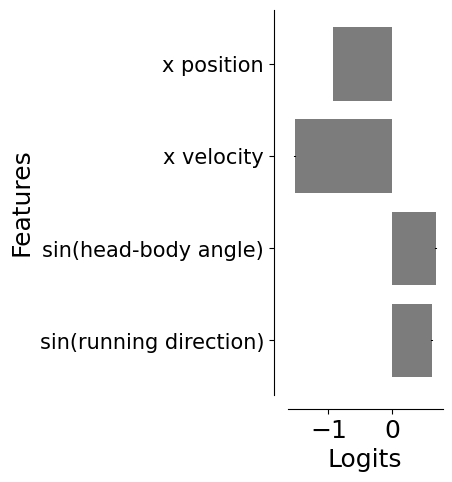

In [19]:
# Logits of the regression
model_labels, clean_labels = (LabelSet.Member * Label & model_key).fetch("label_key", "clean_name")

fig, ax = plt.subplots(1, 1, figsize=(2, 5))
ax.barh(
    model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#7C7C7C",
)
sns.despine(offset=10, ax=ax)

ax.set_yticks(np.arange(len(model_labels)))
ax.set_yticklabels(clean_labels, rotation=0, ha="right", fontsize=15)
ax.set_xlabel("Logits")
ax.set_ylabel("Features")

plt.savefig(
    save_fig_path + "figure5_model_logits.svg", transparent=False
)

In [20]:
prediction_df = pd.DataFrame((PredictionModel().SessionPrediction() & model_key & task_type_key).fetch(
    "dataset", "trial", "proba_left", "accuracy", "trial_length", as_dict=True)).explode(["trial", "proba_left", "accuracy", "trial_length"])

In [21]:
df_model = prediction_df.merge(
    interpolated_df[["dataset", "trial_length", "trial", "aperture", "trial_left_choice", "x", "y"]], on=["dataset", "trial", "trial_length"]
)

df_model["accuracy"] = df_model["accuracy"].astype(float)
df_model["proba_left"] = df_model["proba_left"].astype(float)

In [22]:
df_model.aperture

0          6.0
1          6.0
2          6.0
3          6.0
4          6.0
          ... 
508395    12.0
508396    12.0
508397    12.0
508398    12.0
508399    12.0
Name: aperture, Length: 508400, dtype: float64

In [23]:
df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()

,dataset,aperture,trial_left_choice,trial_length,trial,proba_left,accuracy,x,y
0,31726_2025-03-27_1,3.0,0.0,0.0,65.333333,0.458908,0.666667,-0.582449,-4.037113
1,31726_2025-03-27_1,3.0,0.0,0.01,65.333333,0.446521,0.666667,-0.535250,-3.720957
2,31726_2025-03-27_1,3.0,0.0,0.02,65.333333,0.439584,0.555556,-0.499531,-3.407537
3,31726_2025-03-27_1,3.0,0.0,0.03,65.333333,0.433147,0.555556,-0.466282,-3.128306
4,31726_2025-03-27_1,3.0,0.0,0.04,65.333333,0.427741,0.666667,-0.425038,-2.906881
...,...,...,...,...,...,...,...,...,...
24995,Pheasant_2024-08-28_1,12.0,1.0,0.95,123.580645,0.964455,1.000000,-16.452729,17.461180
24996,Pheasant_2024-08-28_1,12.0,1.0,0.96,123.580645,0.963760,1.000000,-16.606967,17.579616
24997,Pheasant_2024-08-28_1,12.0,1.0,0.97,123.580645,0.963022,1.000000,-16.756131,17.692324
24998,Pheasant_2024-08-28_1,12.0,1.0,0.98,123.580645,0.961597,1.000000,-16.888200,17.786801


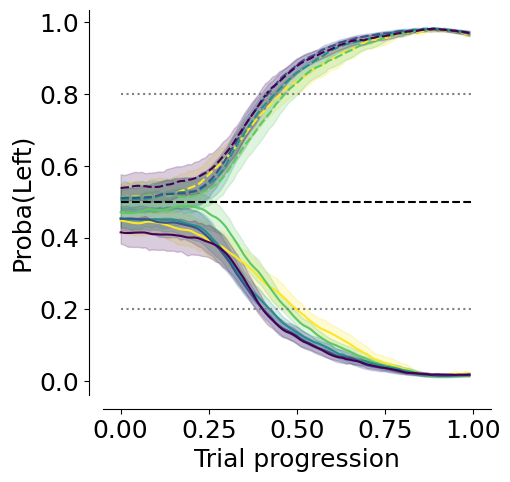

In [24]:
df_model_mean = df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dash_styles = {
    df_model_mean.aperture.unique()[0]: "",         # Solid
    df_model_mean.aperture.unique()[1]: (5, 5)      # Dashed
}
    
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="proba_left",
    hue="aperture",
    style="trial_left_choice",
    palette=plotting.colors_multi_aperture,
    sort=False,
    alpha=1,
    ax=ax,
)

ax.hlines(0.5, xmin=0, xmax=1, colors="black", linestyles="dashed")
ax.hlines(0.8, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.hlines(0.2, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(
    save_fig_path + "figure5_dynamic_decision_variable_mean.svg", transparent=True
)
plt.savefig(
    save_fig_path + "figure5_dynamic_decision_variable_mean.png", transparent=True, dpi=300
)

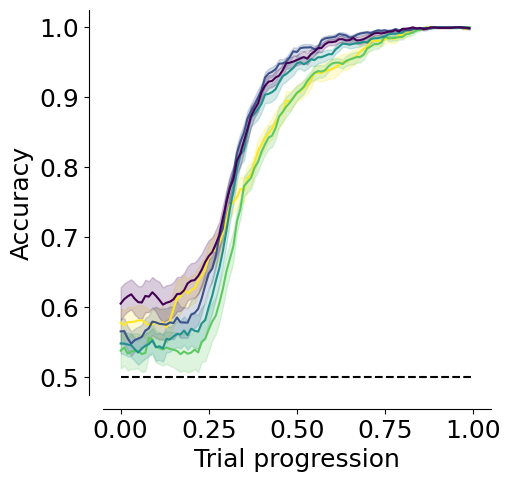

In [25]:
# Accuracy
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_length"], as_index=False).mean()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.lineplot(
    ax=ax,
    data=df_model_mean,
    y="accuracy",
    x="trial_length",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    errorbar="se",
)
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Accuracy")
ax.hlines(0.5, 0, 1, color="black", linestyle="--")
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "figure5_model_accuracy.svg", transparent=False
)

In [ ]:
df_model["trial_length_bin"] = pd.cut(
    df_model["trial_length"], bins=50
)

df_anova = df_model.groupby(
    ["dataset", "aperture", "trial_length_bin"], as_index=False
).mean(numeric_only=True)

print(
    AnovaRM(
        data=df_anova,
        depvar="accuracy",
        subject="dataset",
        within=["aperture", "trial_length_bin"],
    ).fit()
)

                           Anova
                          F Value   Num DF    Den DF  Pr > F
------------------------------------------------------------
aperture                   11.6394   4.0000   96.0000 0.0000
trial_length_bin          479.8480  29.0000  696.0000 0.0000
aperture:trial_length_bin   4.5217 116.0000 2784.0000 0.0000



## Get the decision points

In [ ]:
decision_points = pd.DataFrame((DecisionPoints() & task_type_key & model_key & "threshold_uncertainty = 0.2").fetch(as_dict=True))
decision_points = decision_points.explode(["trial", "aperture", "trial_length", "trial_left_choice", "proba_left", "x", "y", "trial_rewarded"])
decision_points["mouse_name"] = decision_points.dataset.str.split("_").str[0]
decision_points["y"] = decision_points["y"].astype(float)

### Get distance to screen at decision point

3.0-4.2: TtestResult(statistic=0.49739267320565256, pvalue=0.6234385950886467, df=24)
 mean difference:  -0.4588393517271001
3.0-6.0: TtestResult(statistic=1.693880063404927, pvalue=0.10322884643216759, df=24)
 mean difference:  -1.4844673241082784
3.0-8.48: TtestResult(statistic=3.1792023984838473, pvalue=0.004038831906936139, df=24)
 mean difference:  -2.471162040680559
mean: 13.497117945523021 +/- 0.5902315830199871
4.2-6.0: TtestResult(statistic=1.4004289297852808, pvalue=0.1741812780717876, df=24)
 mean difference:  -1.0256279723811783
4.2-8.48: TtestResult(statistic=2.7248202118290044, pvalue=0.011813735411151478, df=24)
 mean difference:  -2.012322688953459
mean: 13.038278593795921 +/- 0.5588690162720868
6.0-8.48: TtestResult(statistic=1.5436863271887404, pvalue=0.135748808870696, df=24)
 mean difference:  -0.9866947165722806
mean: 12.012650621414743 +/- 0.49183009302876524
mean: 11.025955904842462 +/- 0.4311999013527618
12.0-3.0: TtestResult(statistic=-3.942764100540485, pvalue

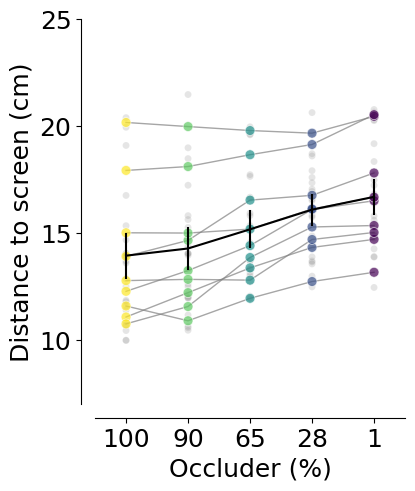

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
_ = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.set_ylim(7, 25)
ax.set_xlim(-0.5, 4.5)
ax.set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure5_decision_points_distance.svg",
    transparent=True,
)

In [ ]:
decision_points["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    decision_points.loc[decision_points.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

3.0-4.2: TtestResult(statistic=1.642537561074118, pvalue=0.11351827397368137, df=24)
 mean difference:  -0.45883935172709833
3.0-6.0: TtestResult(statistic=4.2983466586465715, pvalue=0.00024733745617359606, df=24)
 mean difference:  -1.4844673241082784
3.0-8.48: TtestResult(statistic=6.155926130065273, pvalue=2.3250750840673953e-06, df=24)
 mean difference:  -2.4711620406805572
mean: 13.49711794552302 +/- 0.5902315830199871
4.2-6.0: TtestResult(statistic=3.10821148732398, pvalue=0.004792130413702259, df=24)
 mean difference:  -1.02562797238118
4.2-8.48: TtestResult(statistic=4.974868865020553, pvalue=4.430266888757864e-05, df=24)
 mean difference:  -2.012322688953459
mean: 13.038278593795921 +/- 0.5588690162720868
6.0-8.48: TtestResult(statistic=5.2375325199351295, pvalue=2.2800072677224504e-05, df=24)
 mean difference:  -0.9866947165722788
mean: 12.01265062141474 +/- 0.49183009302876524
mean: 11.025955904842462 +/- 0.4311999013527618
12.0-3.0: TtestResult(statistic=-9.208450288570099,

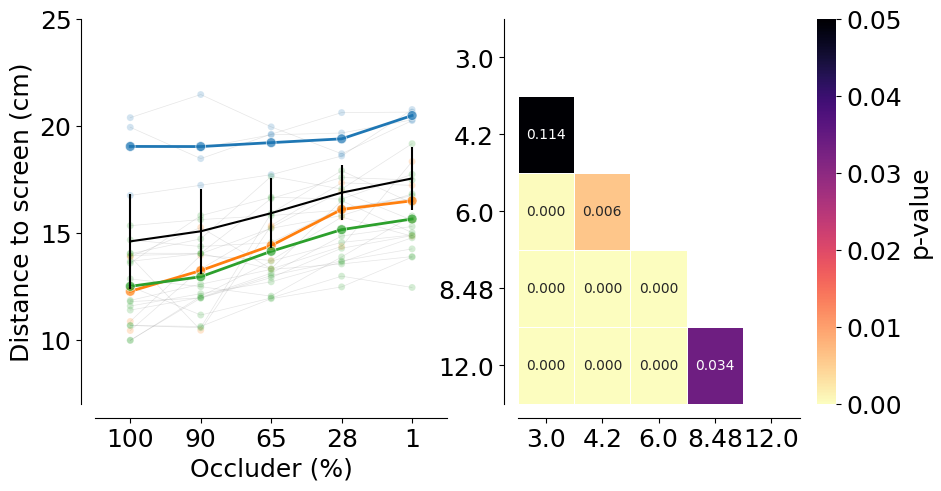

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

_ = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[0].set_ylim(7, 25)
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

p_values = get_multi_p_values_global(decision_points,  y_var="y")
plot_aperture_heatmap(p_values, ax= ax[1])

sns.despine(offset=10, ax=ax[1])

decision_points_anova = decision_points.groupby(["dataset", "aperture"], as_index=False)[
    "y"
].mean()
print(AnovaRM(decision_points_anova, depvar="y", subject="dataset", within=["aperture"]).fit())


plt.savefig(
    save_fig_path + "figure5_decision_points_distance_per_lab.svg",
    transparent=True,
)